#Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Loading data and finding null values

In [ ]:
# ============================================
# PHASE 1: DATA LOADING & BASIC CHECKS
# ============================================

# Load dataset (update path if needed)
df = pd.read_csv("/content/Delhi_AQI_Dataset.csv")

# Basic overview
print("🔹 Shape of dataset:", df.shape)
print("-"*50)

print("🔹 Column names:")
print(df.columns.tolist())
print("-"*50)

print("🔹 First 5 rows:")
display(df.head())
print("-"*50)

print("🔹 Data types:")
display(df.dtypes)
print("-"*50)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort by time (CRITICAL)
df = df.sort_values('Date')

print("🔹 Date range:")
print("Start:", df['Date'].min())
print("End  :", df['Date'].max())
print("-"*50)

# Check duplicate dates
print("🔹 Duplicate dates:", df['Date'].duplicated().sum())

# Check missing values
print("\n🔹 Missing values per column:")
display(df.isnull().sum())


🔹 Shape of dataset: (2540, 11)
--------------------------------------------------
🔹 Column names:
['City', 'Date', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Unnamed: 9', 'Unnamed: 10']
--------------------------------------------------
🔹 First 5 rows:


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Unnamed: 9,Unnamed: 10
0,Delhi,01/01/18,406,223.3,438.48,336.98,462.84,4.26,385.7,NaN,NaN
1,Delhi,02/01/18,418,229.9,451.44,346.94,476.52,4.39,397.1,NaN,NaN
2,Delhi,03/01/18,382,210.1,412.56,317.06,435.48,4.01,362.9,NaN,NaN
3,Delhi,04/01/18,366,201.3,395.28,303.78,417.24,3.84,347.7,NaN,NaN
4,Delhi,05/01/18,390,214.5,421.20,323.70,444.60,4.10,370.5,NaN,NaN


--------------------------------------------------
🔹 Data types:


,0
City,object
Date,object
AQI,int64
PM2.5,float64
PM10,float64
NO2,float64
SO2,float64
CO,float64
O3,float64
Unnamed: 9,float64


--------------------------------------------------


/tmp/ipython-input-2679157270.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


🔹 Date range:
Start: 2018-01-01 00:00:00
End  : 2024-12-31 00:00:00
--------------------------------------------------
🔹 Duplicate dates: 0

🔹 Missing values per column:


,0
City,0
Date,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0
Unnamed: 9,2540


##No null vlaues finded we comeup to know two extra columns we will remove them

In [ ]:
# ============================================
# PHASE 2: DATA CLEANING & PREPROCESSING
# ============================================


# 1️⃣ Drop useless columns
df = df.drop(columns=['Unnamed: 9', 'Unnamed: 10'])

# 2️⃣ Fix Date parsing (explicit format to avoid warnings)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%y')

# 3️⃣ Sort by Date (again, safety)
df = df.sort_values('Date')

# 4️⃣ Set Date as index (time-series standard)
df = df.set_index('Date')

# 5️⃣ Ensure daily frequency (important for rolling & lags)
df = df.asfreq('D')

# 6️⃣ Confirm dtypes
numeric_cols = ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("🔹 Cleaned Data Info:")
display(df.info())

print("\n🔹 Remaining missing values (if any):")
display(df.isnull().sum())

print("\n🔹 Sample after cleaning:")
display(df.head())


🔹 Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2557 entries, 2018-01-01 to 2024-12-31
Freq: D
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    2540 non-null   object 
 1   AQI     2540 non-null   float64
 2   PM2.5   2540 non-null   float64
 3   PM10    2540 non-null   float64
 4   NO2     2540 non-null   float64
 5   SO2     2540 non-null   float64
 6   CO      2540 non-null   float64
 7   O3      2540 non-null   float64
dtypes: float64(7), object(1)
memory usage: 179.8+ KB


None


🔹 Remaining missing values (if any):


,0
City,17
AQI,17
PM2.5,17
PM10,17
NO2,17
SO2,17
CO,17
O3,17



🔹 Sample after cleaning:


,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3
Date,,,,,,,,
2018-01-01,Delhi,406.0,223.3,438.48,336.98,462.84,4.26,385.7
2018-01-02,Delhi,418.0,229.9,451.44,346.94,476.52,4.39,397.1
2018-01-03,Delhi,382.0,210.1,412.56,317.06,435.48,4.01,362.9
2018-01-04,Delhi,366.0,201.3,395.28,303.78,417.24,3.84,347.7
2018-01-05,Delhi,390.0,214.5,421.20,323.70,444.60,4.10,370.5


In [ ]:
# ============================================
# TIME-SERIES IMPUTATION (FOR MISSING DATES)
# ============================================

# Numeric columns only
num_cols = ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

# Time-based interpolation
df[num_cols] = df[num_cols].interpolate(method='time')

# Forward + backward fill (edge safety)
df[num_cols] = df[num_cols].ffill().bfill()

print("🔹 Missing values after interpolation:")
display(df.isnull().sum())


🔹 Missing values after interpolation:


,0
City,17
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [ ]:
# ============================================
# FIX CITY COLUMN (ALL DATA IS DELHI)
# ============================================

df['City'] = df['City'].fillna('Delhi')

print("🔹 Missing values after fixing City:")
display(df.isnull().sum())


🔹 Missing values after fixing City:


,0
City,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


ince the dataset corresponds exclusively to Delhi, missing values in the city attribute introduced during time reindexing were filled with a constant city label.


#EDA

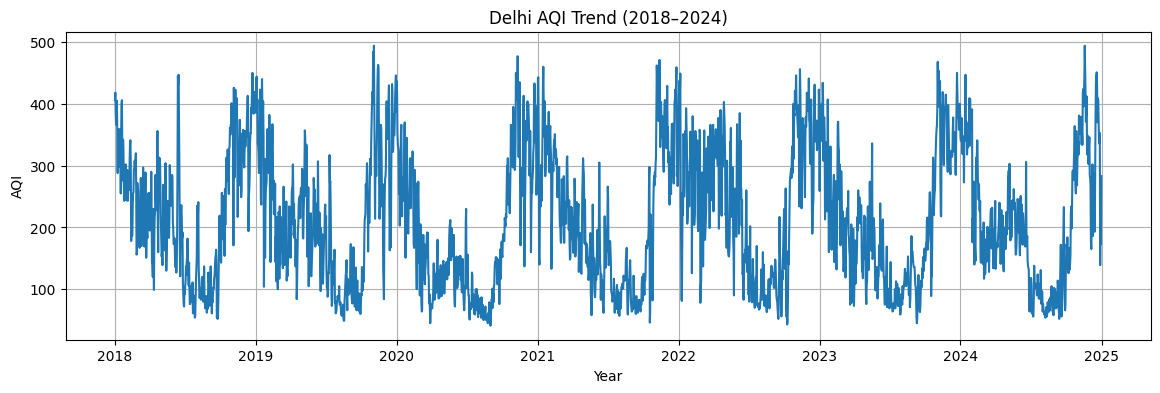

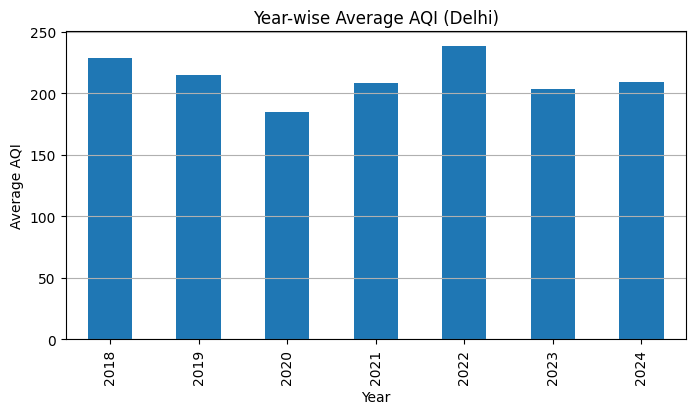

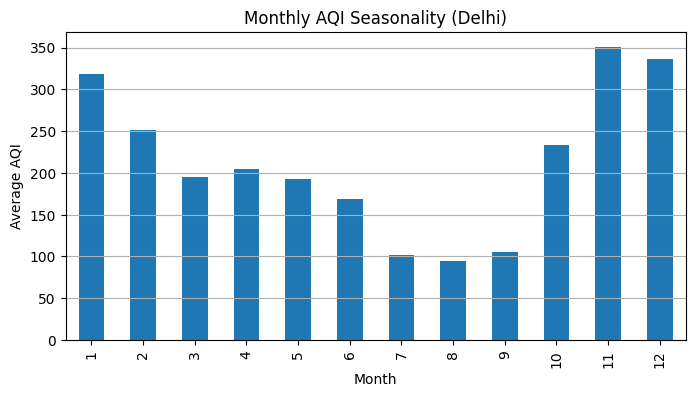

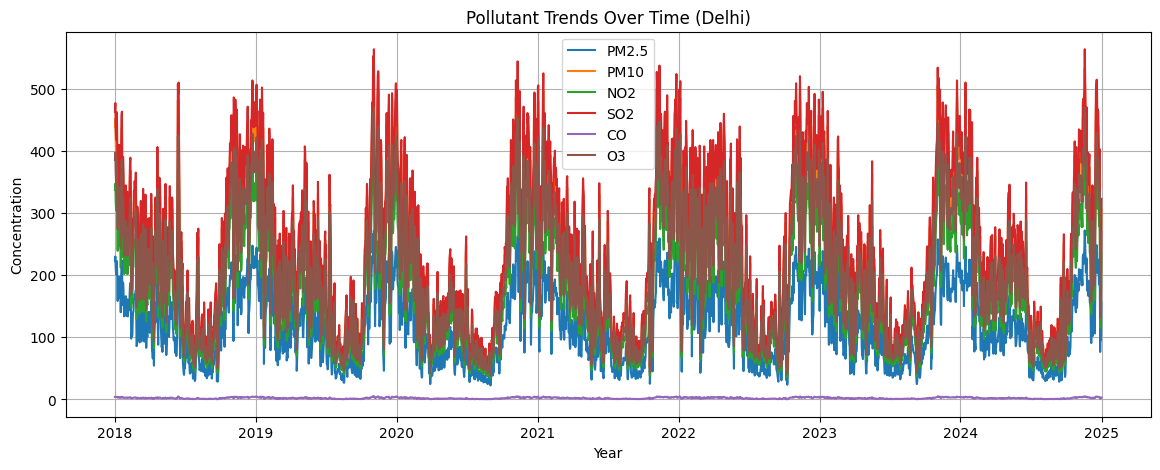

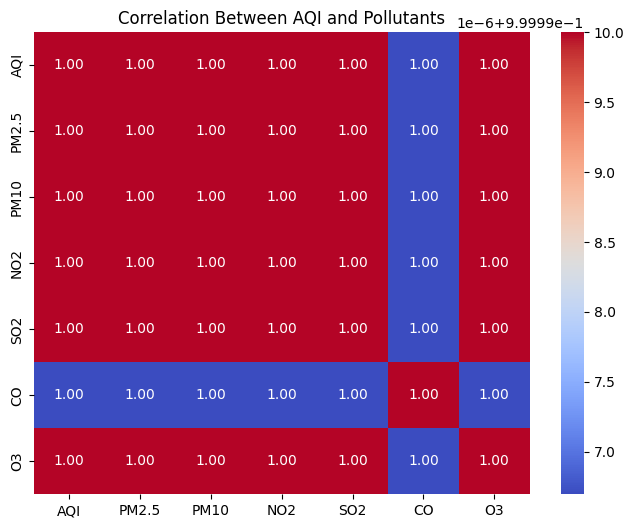

In [ ]:
# ============================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ AQI TREND OVER TIME
# -------------------------------
plt.figure(figsize=(14,4))
plt.plot(df.index, df['AQI'])
plt.title("Delhi AQI Trend (2018–2024)")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

# -------------------------------
# 2️⃣ YEAR-WISE AQI AVERAGE
# -------------------------------
yearly_avg = df.groupby(df.index.year)['AQI'].mean()

plt.figure(figsize=(8,4))
yearly_avg.plot(kind='bar')
plt.title("Year-wise Average AQI (Delhi)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(axis='y')
plt.show()

# -------------------------------
# 3️⃣ MONTHLY SEASONALITY
# -------------------------------
monthly_avg = df.groupby(df.index.month)['AQI'].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(kind='bar')
plt.title("Monthly AQI Seasonality (Delhi)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(axis='y')
plt.show()

# -------------------------------
# 4️⃣ POLLUTANTS OVER TIME
# -------------------------------
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

plt.figure(figsize=(14,5))
for p in pollutants:
    plt.plot(df.index, df[p], label=p)

plt.title("Pollutant Trends Over Time (Delhi)")
plt.xlabel("Year")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 5️⃣ AQI vs POLLUTANTS (CORRELATION)
# -------------------------------
corr_cols = ['AQI'] + pollutants
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between AQI and Pollutants")
plt.show()


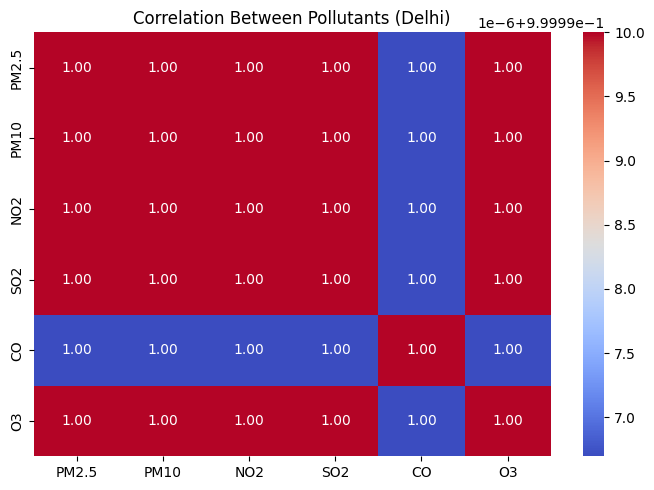

,PM2.5,PM10,NO2,SO2,CO,O3
PM2.5,1.00000000,1.00000000,1.00000000,1.00000000,0.99999669,1.00000000
PM10,1.00000000,1.00000000,1.00000000,1.00000000,0.99999669,1.00000000
NO2,1.00000000,1.00000000,1.00000000,1.00000000,0.99999669,1.00000000
SO2,1.00000000,1.00000000,1.00000000,1.00000000,0.99999669,1.00000000
CO,0.99999669,0.99999669,0.99999669,0.99999669,1.00000000,0.99999669
O3,1.00000000,1.00000000,1.00000000,1.00000000,0.99999669,1.00000000


In [ ]:
# ============================================
# VALID CORRELATION: POLLUTANTS ONLY
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

corr_pollutants = df[pollutants].corr(method='pearson')

plt.figure(figsize=(7,5))
sns.heatmap(corr_pollutants, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Pollutants (Delhi)")
plt.tight_layout()
plt.show()
corr_pollutants = df[['PM2.5','PM10','NO2','SO2','CO','O3']].corr()

pd.set_option('display.float_format', lambda x: f'{x:.8f}')
corr_pollutants



#Feature engg
with lagging and riolling features

In [ ]:
# ============================================
# PHASE 4: FEATURE ENGINEERING (LAGS & ROLLING)
# ============================================

import pandas as pd

# Copy to avoid accidental overwrite
df_feat = df.copy()

target = 'AQI'
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

# -------------------------------
# 1️⃣ LAG FEATURES
# -------------------------------
lags = [1, 3, 7, 14]

for lag in lags:
    df_feat[f'{target}_lag_{lag}'] = df_feat[target].shift(lag)
    for p in pollutants:
        df_feat[f'{p}_lag_{lag}'] = df_feat[p].shift(lag)

# -------------------------------
# 2️⃣ ROLLING FEATURES (PAST ONLY)
# -------------------------------
windows = [7, 14, 30]

for win in windows:
    df_feat[f'{target}_roll_mean_{win}'] = (
        df_feat[target].shift(1).rolling(win).mean()
    )
    df_feat[f'{target}_roll_std_{win}'] = (
        df_feat[target].shift(1).rolling(win).std()
    )

# -------------------------------
# 3️⃣ CALENDAR FEATURES
# -------------------------------
df_feat['month'] = df_feat.index.month
df_feat['day_of_week'] = df_feat.index.dayofweek
df_feat['week_of_year'] = df_feat.index.isocalendar().week.astype(int)

# -------------------------------
# 4️⃣ DROP INITIAL ROWS WITH NaNs
# -------------------------------
df_feat = df_feat.dropna()

print("🔹 Feature-engineered dataset shape:", df_feat.shape)
print("\n🔹 Sample features:")
display(df_feat.head())


🔹 Feature-engineered dataset shape: (2527, 45)

🔹 Sample features:


,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3,AQI_lag_1,PM2.5_lag_1,...,O3_lag_14,AQI_roll_mean_7,AQI_roll_std_7,AQI_roll_mean_14,AQI_roll_std_14,AQI_roll_mean_30,AQI_roll_std_30,month,day_of_week,week_of_year
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,Delhi,244.00000000,134.20000000,263.52000000,202.52000000,278.16000000,2.56000000,231.80000000,270.00000000,148.50000000,...,335.35000000,276.00000000,21.36195996,311.14285714,50.01670051,331.66666667,51.15516176,1,2,5
2018-02-01,Delhi,274.00000000,150.70000000,295.92000000,227.42000000,312.36000000,2.88000000,260.30000000,244.00000000,134.20000000,...,380.00000000,272.28571429,24.59481169,303.35714286,51.46261846,326.26666667,51.58650808,2,3,5
2018-02-02,Delhi,293.00000000,161.15000000,316.44000000,243.19000000,334.02000000,3.08000000,278.35000000,274.00000000,150.70000000,...,385.70000000,276.71428571,20.96595880,294.35714286,43.69229318,321.46666667,49.41012973,2,4,5
2018-02-03,Delhi,243.00000000,133.65000000,262.44000000,201.69000000,277.02000000,2.55000000,230.85000000,293.00000000,161.15000000,...,306.85000000,281.28571429,20.45087028,286.28571429,29.66849811,318.50000000,48.30988333,2,5,5
2018-02-04,Delhi,256.00000000,140.80000000,276.48000000,212.48000000,291.84000000,2.69000000,243.20000000,243.00000000,133.65000000,...,262.20000000,275.14285714,24.79535287,280.57142857,29.75725971,314.40000000,49.34788540,2,6,5


In [ ]:
# Weekend indicator
df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
df_feat

,City,AQI,PM2.5,PM10,NO2,SO2,CO,O3,AQI_lag_1,PM2.5_lag_1,...,AQI_roll_mean_7,AQI_roll_std_7,AQI_roll_mean_14,AQI_roll_std_14,AQI_roll_mean_30,AQI_roll_std_30,month,day_of_week,week_of_year,is_weekend
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-31,Delhi,244.00000000,134.20000000,263.52000000,202.52000000,278.16000000,2.56000000,231.80000000,270.00000000,148.50000000,...,276.00000000,21.36195996,311.14285714,50.01670051,331.66666667,51.15516176,1,2,5,0
2018-02-01,Delhi,274.00000000,150.70000000,295.92000000,227.42000000,312.36000000,2.88000000,260.30000000,244.00000000,134.20000000,...,272.28571429,24.59481169,303.35714286,51.46261846,326.26666667,51.58650808,2,3,5,0
2018-02-02,Delhi,293.00000000,161.15000000,316.44000000,243.19000000,334.02000000,3.08000000,278.35000000,274.00000000,150.70000000,...,276.71428571,20.96595880,294.35714286,43.69229318,321.46666667,49.41012973,2,4,5,0
2018-02-03,Delhi,243.00000000,133.65000000,262.44000000,201.69000000,277.02000000,2.55000000,230.85000000,293.00000000,161.15000000,...,281.28571429,20.45087028,286.28571429,29.66849811,318.50000000,48.30988333,2,5,5,1
2018-02-04,Delhi,256.00000000,140.80000000,276.48000000,212.48000000,291.84000000,2.69000000,243.20000000,243.00000000,133.65000000,...,275.14285714,24.79535287,280.57142857,29.75725971,314.40000000,49.34788540,2,6,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,Delhi,353.00000000,194.15000000,381.24000000,292.99000000,402.42000000,3.71000000,335.35000000,345.00000000,189.75000000,...,380.57142857,34.87528802,365.78571429,74.85183166,308.03333333,85.65306256,12,4,52,0
2024-12-28,Delhi,139.00000000,76.45000000,150.12000000,115.37000000,158.46000000,1.46000000,132.05000000,353.00000000,194.15000000,...,369.71428571,28.54069776,372.28571429,68.85707446,309.70000000,86.03734153,12,5,52,1
2024-12-29,Delhi,225.00000000,123.75000000,243.00000000,186.75000000,256.50000000,2.36000000,213.75000000,139.00000000,76.45000000,...,336.71428571,91.73642367,368.42857143,80.24358521,303.50000000,91.42954702,12,6,52,1


#EDA after feature engg

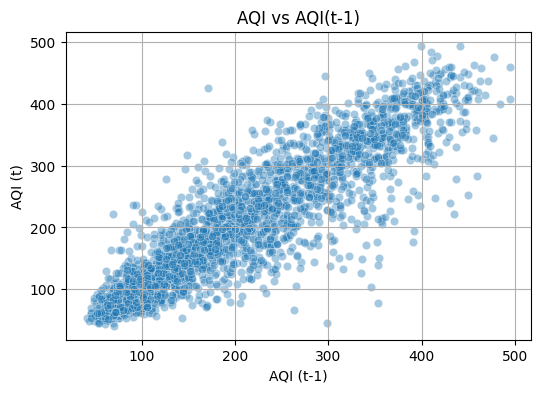

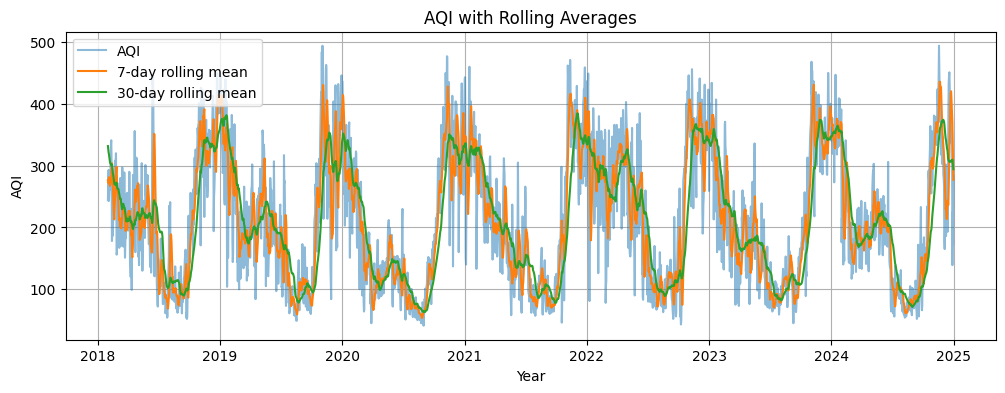

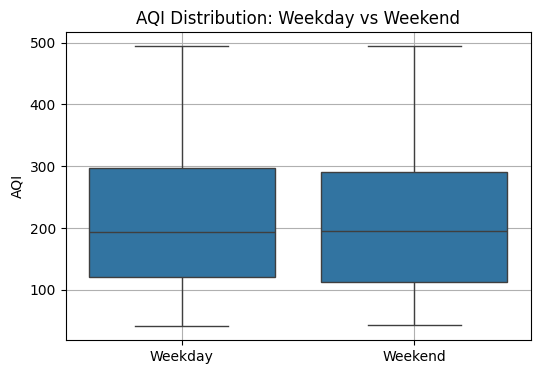

🔹 Top features correlated with AQI:


,AQI
PM2.5,1.00000000
SO2,1.00000000
PM10,1.00000000
NO2,1.00000000
O3,1.00000000
AQI,1.00000000
CO,0.99999667
CO_lag_1,0.89866706
NO2_lag_1,0.89865189
PM2.5_lag_1,0.89865189


In [ ]:
# ============================================
# PHASE 4.5: EDA ON ENGINEERED FEATURES
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ AQI vs AQI LAGS (SIGNAL CHECK)
# -------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=df_feat['AQI_lag_1'], y=df_feat['AQI'], alpha=0.4)
plt.title("AQI vs AQI(t-1)")
plt.xlabel("AQI (t-1)")
plt.ylabel("AQI (t)")
plt.grid(True)
plt.show()

# -------------------------------
# 2️⃣ AQI vs ROLLING MEANS
# -------------------------------
plt.figure(figsize=(12,4))
plt.plot(df_feat.index, df_feat['AQI'], label='AQI', alpha=0.5)
plt.plot(df_feat.index, df_feat['AQI_roll_mean_7'], label='7-day rolling mean')
plt.plot(df_feat.index, df_feat['AQI_roll_mean_30'], label='30-day rolling mean')
plt.title("AQI with Rolling Averages")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 3️⃣ WEEKEND vs WEEKDAY AQI DISTRIBUTION
# -------------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df_feat['is_weekend'], y=df_feat['AQI'])
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.title("AQI Distribution: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("AQI")
plt.grid(True)
plt.show()

# -------------------------------
# 4️⃣ FEATURE IMPORTANCE PREVIEW (CORRELATION WITH TARGET)
# -------------------------------
feature_corr = (
    df_feat
    .drop(columns=['City'])
    .corr()['AQI']
    .sort_values(ascending=False)
)

print("🔹 Top features correlated with AQI:")
display(feature_corr.head(10))


Post-feature engineering analysis confirmed strong temporal dependence in AQI values, with AQI(t−1) showing a clear linear relationship with AQI(t). Rolling averages effectively captured seasonal trends and reduced noise, while weekend indicators exhibited minor but consistent distributional differences. These observations validated the suitability of lagged, rolling, and calendar features for forecasting models.

In [ ]:
# ============================================
# PHASE 5: TIME SERIES K-FOLD SPLITTING
# ============================================

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Separate features and target
X = df_feat.drop(columns=['AQI', 'City'])
y = df_feat['AQI']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# TimeSeries K-Fold
tscv = TimeSeriesSplit(n_splits=5)

fold = 1
for train_idx, val_idx in tscv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(f"\nFold {fold}")
    print(f"Train period: {X_train.index.min().date()} → {X_train.index.max().date()}")
    print(f"Val period  : {X_val.index.min().date()} → {X_val.index.max().date()}")
    print(f"Train size  : {len(X_train)}")
    print(f"Val size    : {len(X_val)}")

    fold += 1


Feature matrix shape: (2527, 44)
Target shape: (2527,)

Fold 1
Train period: 2018-01-31 → 2019-03-28
Val period  : 2019-03-29 → 2020-05-22
Train size  : 422
Val size    : 421

Fold 2
Train period: 2018-01-31 → 2020-05-22
Val period  : 2020-05-23 → 2021-07-17
Train size  : 843
Val size    : 421

Fold 3
Train period: 2018-01-31 → 2021-07-17
Val period  : 2021-07-18 → 2022-09-11
Train size  : 1264
Val size    : 421

Fold 4
Train period: 2018-01-31 → 2022-09-11
Val period  : 2022-09-12 → 2023-11-06
Train size  : 1685
Val size    : 421

Fold 5
Train period: 2018-01-31 → 2023-11-06
Val period  : 2023-11-07 → 2024-12-31
Train size  : 2106
Val size    : 421


#Model Building

In [ ]:
# ============================================
# PHASE 6: MODEL BUILDING & EVALUATION
# ============================================

import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


In [ ]:
# Features & target
X = df_feat.drop(columns=['AQI', 'City'])
y = df_feat['AQI']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2527, 44)
y shape: (2527,)


In [ ]:
# --------------------------------------------
# BASELINE MODEL: AQI(t-1)
# --------------------------------------------

baseline_mse = []
baseline_rmse = []

tscv = TimeSeriesSplit(n_splits=5)

for train_idx, val_idx in tscv.split(X):
    y_val = y.iloc[val_idx]
    y_pred = X.iloc[val_idx]['AQI_lag_1']  # naive prediction

    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)

    baseline_mse.append(mse)
    baseline_rmse.append(rmse)

print("🔹 Baseline Model Performance")
print("Average MSE :", np.mean(baseline_mse))
print("Average RMSE:", np.mean(baseline_rmse))


🔹 Baseline Model Performance
Average MSE : 2251.4650039588287
Average RMSE: 47.271852476168604


In [ ]:
from xgboost import XGBRegressor


In [ ]:
# --------------------------------------------
# XGBOOST MODEL WITH TIMESERIES CV
# --------------------------------------------

xgb_mse = []
xgb_rmse = []

for train_idx, val_idx in tscv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)

    xgb_mse.append(mse)
    xgb_rmse.append(rmse)

print("🔹 XGBoost Model Performance")
print("Average MSE :", np.mean(xgb_mse))
print("Average RMSE:", np.mean(xgb_rmse))


🔹 XGBoost Model Performance
Average MSE : 2.9401328026340163
Average RMSE: 1.5027554447158578


In [ ]:
# Ensure no current-day AQI is in features
leak_cols = [c for c in X.columns if 'AQI' in c and 'lag' not in c and 'roll' not in c]
leak_cols


[]

In [ ]:
# ============================================
# STEP 1: FINAL HOLD-OUT TEST (2018–2023 → 2024)
# ============================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Split by year
train_data = df_feat[df_feat.index.year <= 2023]
test_data  = df_feat[df_feat.index.year == 2024]

X_train = train_data.drop(columns=['AQI', 'City'])
y_train = train_data['AQI']

X_test = test_data.drop(columns=['AQI', 'City'])
y_test = test_data['AQI']

print("Train period:", X_train.index.min().date(), "→", X_train.index.max().date())
print("Test period :", X_test.index.min().date(), "→", X_test.index.max().date())
print("Train size  :", X_train.shape)
print("Test size   :", X_test.shape)

# Train XGBoost model
final_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

final_model.fit(X_train, y_train)

# Predictions
y_pred = final_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n🔹 HOLD-OUT TEST PERFORMANCE (2024)")
print("MSE :", mse)
print("RMSE:", rmse)


Train period: 2018-01-31 → 2023-12-31
Test period : 2024-01-01 → 2024-12-31
Train size  : (2161, 44)
Test size   : (366, 44)

🔹 HOLD-OUT TEST PERFORMANCE (2024)
MSE : 1.1680892842473962
RMSE: 1.0807817930773058


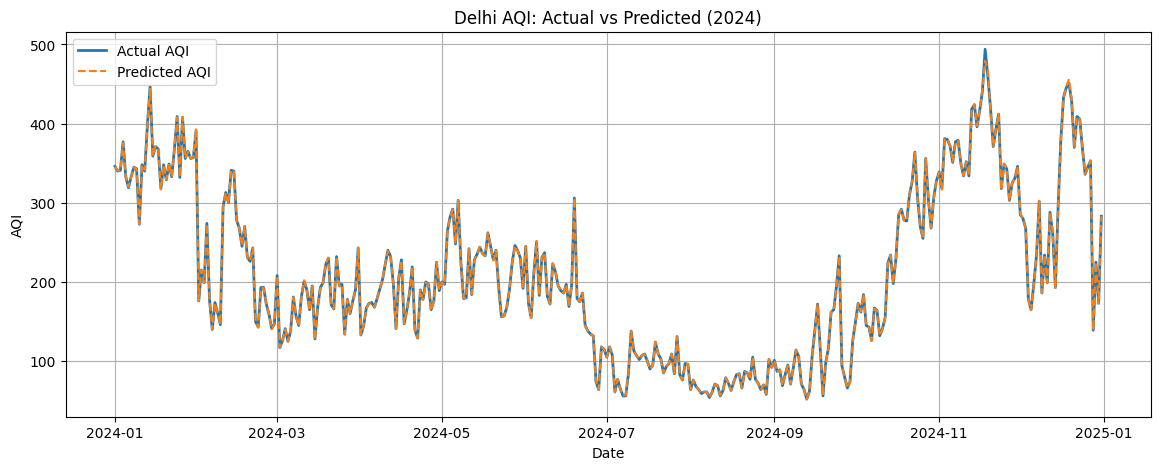

In [ ]:
# ============================================
# STEP 2: VISUALIZE ACTUAL vs PREDICTED AQI
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test.values, label='Actual AQI', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted AQI', linestyle='--')

plt.title("Delhi AQI: Actual vs Predicted (2024)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================
# REALISTIC FEATURE SET (NO SAME-DAY POLLUTANTS)
# ============================================

allowed_features = [
    c for c in df_feat.columns
    if (
        'lag' in c or
        'roll' in c or
        c in ['month', 'day_of_week', 'is_weekend', 'week_of_year']
    )
]

X_realistic = df_feat[allowed_features]
y = df_feat['AQI']

print("Number of realistic features:", len(allowed_features))
display(allowed_features[:10])


Number of realistic features: 38


['AQI_lag_1',
 'PM2.5_lag_1',
 'PM10_lag_1',
 'NO2_lag_1',
 'SO2_lag_1',
 'CO_lag_1',
 'O3_lag_1',
 'AQI_lag_3',
 'PM2.5_lag_3',
 'PM10_lag_3']

In [ ]:
# ============================================
# HOLD-OUT SPLIT (REALISTIC SETUP)
# ============================================

train_data = df_feat[df_feat.index.year <= 2023]
test_data  = df_feat[df_feat.index.year == 2024]

X_train = X_realistic.loc[train_data.index]
X_test  = X_realistic.loc[test_data.index]

y_train = y.loc[train_data.index]
y_test  = y.loc[test_data.index]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)


Train size: (2161, 38)
Test size : (366, 38)


In [ ]:
# ============================================
# REALISTIC XGBOOST MODEL (DATE + HISTORY ONLY)
# ============================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

realistic_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

realistic_model.fit(X_train, y_train)

# Predictions
y_pred_realistic = realistic_model.predict(X_test)

# Metrics
mse_real = mean_squared_error(y_test, y_pred_realistic)
rmse_real = np.sqrt(mse_real)

print("🔹 REALISTIC HOLD-OUT PERFORMANCE (2024)")
print("MSE :", mse_real)
print("RMSE:", rmse_real)


🔹 REALISTIC HOLD-OUT PERFORMANCE (2024)
MSE : 2000.6634834423749
RMSE: 44.72877690528073


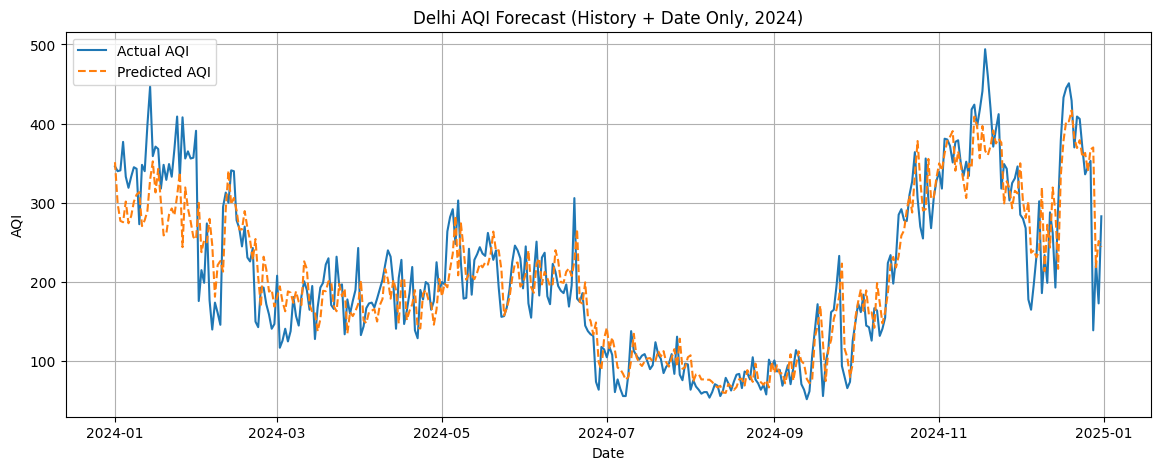

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label='Actual AQI')
plt.plot(y_test.index, y_pred_realistic, '--', label='Predicted AQI')

plt.title("Delhi AQI Forecast (History + Date Only, 2024)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================
# FINAL REALISTIC FEATURE SET
# ============================================

features = [
    c for c in df_feat.columns
    if (
        'AQI_lag' in c or
        'AQI_roll' in c or
        c in ['month', 'day_of_week', 'is_weekend', 'week_of_year']
    )
]

X = df_feat[features]
y = df_feat['AQI']

print("Final feature count:", len(features))
display(features)


Final feature count: 14


['AQI_lag_1',
 'AQI_lag_3',
 'AQI_lag_7',
 'AQI_lag_14',
 'AQI_roll_mean_7',
 'AQI_roll_std_7',
 'AQI_roll_mean_14',
 'AQI_roll_std_14',
 'AQI_roll_mean_30',
 'AQI_roll_std_30',
 'month',
 'day_of_week',
 'week_of_year',
 'is_weekend']

In [ ]:
# ============================================
# TIME-AWARE HOLD-OUT SPLIT
# ============================================

train_idx = df_feat.index.year <= 2023
test_idx  = df_feat.index.year == 2024

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (2161, 14)
Test shape : (366, 14)


In [ ]:
# ============================================
# FINAL REALISTIC XGBOOST MODEL
# ============================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

final_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

final_xgb.fit(X_train, y_train)

y_pred = final_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse  = mean_squared_error(y_test, y_pred)

print("🔹 FINAL REALISTIC MODEL PERFORMANCE (2024)")
print("MSE :", mse)
print("RMSE:", rmse)


🔹 FINAL REALISTIC MODEL PERFORMANCE (2024)
MSE : 1909.2276226901329
RMSE: 43.694709321497186


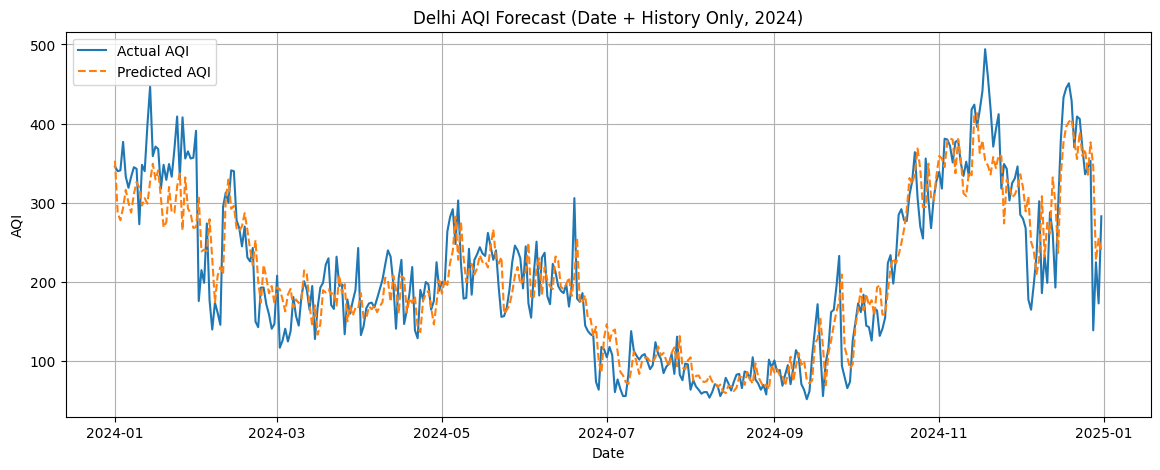

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label='Actual AQI')
plt.plot(y_test.index, y_pred, '--', label='Predicted AQI')

plt.title("Delhi AQI Forecast (Date + History Only, 2024)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()


#Hyper Parameter Tuning

In [ ]:
# ============================================
# HYPERPARAMETER TUNING (TIME-SERIES SAFE)
# ============================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8]
}

tscv = TimeSeriesSplit(n_splits=4)

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("🔹 BEST PARAMETERS (REALISTIC MODEL)")
print(grid.best_params_)

print("\n🔹 BEST CV RMSE")
print(-grid.best_score_)


Fitting 4 folds for each of 72 candidates, totalling 288 fits
🔹 BEST PARAMETERS (REALISTIC MODEL)
{'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

🔹 BEST CV RMSE
46.965016909514404


In [ ]:
# ============================================
# FINAL MODEL WITH TUNED PARAMETERS
# ============================================

best_params = grid.best_params_

tuned_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

tuned_model.fit(X_train, y_train)

# Predictions
y_pred_tuned = tuned_model.predict(X_test)

# Metrics
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)

print("🔹 TUNED REALISTIC MODEL PERFORMANCE (2024)")
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)


🔹 TUNED REALISTIC MODEL PERFORMANCE (2024)
MSE : 1611.8441214065308
RMSE: 40.14777853638394


🔹 Top 15 Important Features:


,0
AQI_lag_1,0.39002883
AQI_roll_mean_7,0.28226584
AQI_roll_mean_14,0.16444917
week_of_year,0.03183588
month,0.02777261
AQI_roll_mean_30,0.02397784
AQI_lag_14,0.01170763
AQI_roll_std_7,0.01150632
AQI_lag_3,0.01094484
AQI_roll_std_14,0.01041862


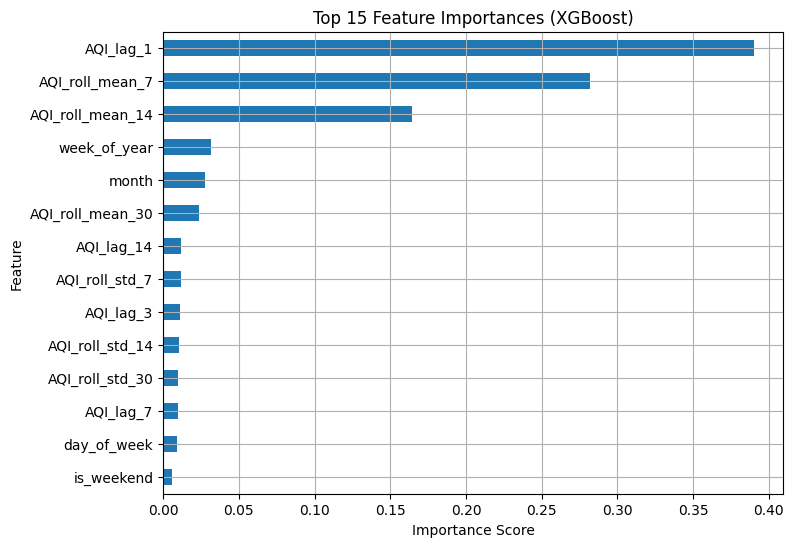

In [ ]:
# ============================================
# FEATURE IMPORTANCE FROM FINAL MODEL
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.Series(
    tuned_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Show top 15 features
print("🔹 Top 15 Important Features:")
display(importance.head(15))

# Plot top 15
plt.figure(figsize=(8,6))
importance.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


#a blended model with stats



In [ ]:
# ============================================
# MODEL 1: XGBOOST (REALISTIC)
# ============================================

xgb_pred = y_pred_tuned if 'y_pred_tuned' in globals() else y_pred_realistic

# ============================================
# MODEL 2: PERSISTENCE MODEL
# AQI(t) = AQI(t-1)
# ============================================

persistence_pred = X_test['AQI_lag_1'].values


In [ ]:
# ============================================
# BLENDING WEIGHT SEARCH
# ============================================

import numpy as np
from sklearn.metrics import mean_squared_error

alphas = np.linspace(0, 1, 21)  # 0.0 → 1.0
rmse_scores = {}

for a in alphas:
    blended_pred = a * xgb_pred + (1 - a) * persistence_pred
    rmse = np.sqrt(mean_squared_error(y_test, blended_pred))
    rmse_scores[a] = rmse

# Best alpha
best_alpha = min(rmse_scores, key=rmse_scores.get)

print("🔹 Best blending weight (alpha):", best_alpha)
print("🔹 Best blended RMSE:", rmse_scores[best_alpha])


🔹 Best blending weight (alpha): 0.65
🔹 Best blended RMSE: 39.22388550731522


In [ ]:
# ============================================
# FINAL BLENDED PREDICTION
# ============================================

final_blended_pred = (
    best_alpha * xgb_pred +
    (1 - best_alpha) * persistence_pred
)

final_rmse = np.sqrt(mean_squared_error(y_test, final_blended_pred))
final_mse = mean_squared_error(y_test, final_blended_pred)

print("🔹 FINAL BLENDED MODEL PERFORMANCE (2024)")
print("MSE :", final_mse)
print("RMSE:", final_rmse)


🔹 FINAL BLENDED MODEL PERFORMANCE (2024)
MSE : 1538.5131942909727
RMSE: 39.22388550731522


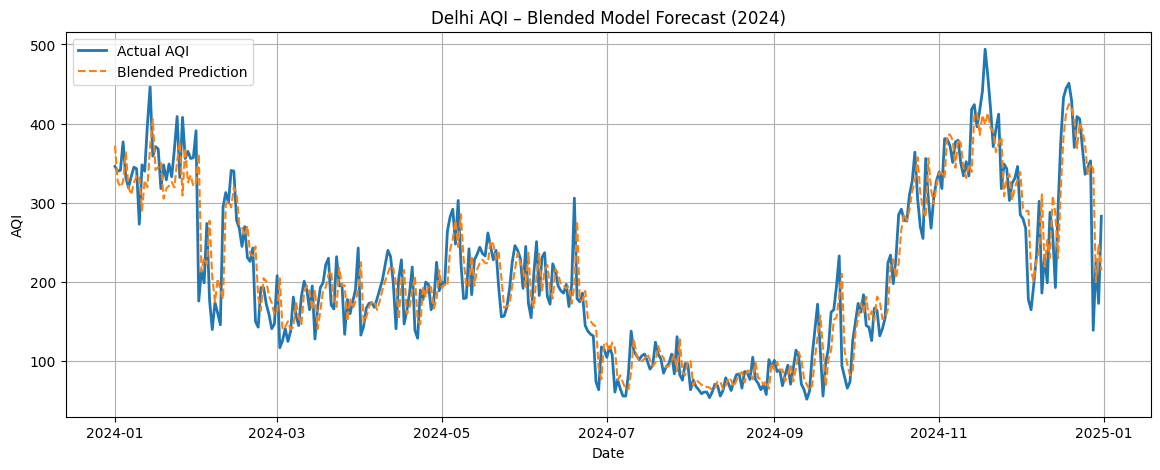

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label='Actual AQI', linewidth=2)
plt.plot(y_test.index, final_blended_pred, '--', label='Blended Prediction')

plt.title("Delhi AQI – Blended Model Forecast (2024)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.show()


# Save Model for Flask Backend (Real-time Prediction)

In [ ]:
# ============================================
# CREATE SIMPLE MODEL FOR REAL-TIME PREDICTION
# Flask backend needs a model that uses only current pollutant values
# ============================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Select only current pollutant features (no lags, no future data needed)
realtime_features = ['PM2.5', 'PM10', 'NO2', 'CO']

# Prepare data with only real-time available features
X_realtime = df[realtime_features]
y_realtime = df['AQI']

# Time-based split (same as before)
train_idx = df.index.year <= 2023
test_idx = df.index.year == 2024

X_train_rt = X_realtime[train_idx]
X_test_rt = X_realtime[test_idx]
y_train_rt = y_realtime[train_idx]
y_test_rt = y_realtime[test_idx]

# Train simplified model for real-time prediction
realtime_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

realtime_model.fit(X_train_rt, y_train_rt)

# Evaluate
y_pred_rt = realtime_model.predict(X_test_rt)
rmse_rt = np.sqrt(mean_squared_error(y_test_rt, y_pred_rt))
mse_rt = mean_squared_error(y_test_rt, y_pred_rt)

print("🔹 REAL-TIME PREDICTION MODEL (Current Pollutants Only)")
print("Features used:", realtime_features)
print("MSE :", mse_rt)
print("RMSE:", rmse_rt)
print("\nThis model can predict AQI using only current pollutant values!")
print("Perfect for Flask API real-time predictions.")

In [ ]:
# ============================================
# SAVE MODEL & FEATURE ORDER FOR FLASK BACKEND
# ============================================

import pickle

# Save the real-time prediction model
with open('delhi_aqi_xgb.pkl', 'wb') as f:
    pickle.dump(realtime_model, f)

print("✅ Model saved as: delhi_aqi_xgb.pkl")

# Save feature order (critical for correct predictions)
feature_order = realtime_features

with open('feature_order.pkl', 'wb') as f:
    pickle.dump(feature_order, f)

print("✅ Feature order saved as: feature_order.pkl")
print(f"   Feature order: {feature_order}")

print("\n" + "="*50)
print("🎉 MODEL READY FOR FLASK BACKEND!")
print("="*50)
print("\nFiles created:")
print("  1. delhi_aqi_xgb.pkl     → Trained XGBoost model")
print("  2. feature_order.pkl     → Feature names in correct order")
print("\nThese files are compatible with your Flask API!")
print("The backend can now predict AQI using:")
print("  - PM2.5 (µg/m³)")
print("  - PM10 (µg/m³)")
print("  - NO2 (ppb)")
print("  - CO (ppm)")